# Statistiques Word Structure sur le S4 Gold

In [2]:
import re,codecs,yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def ding():
    os.system('afplay /System/Library/Sounds/Submarine.aiff')

%store -r ordStemCells

In [3]:
sns.set_style("whitegrid")

In [4]:
repFiles="/Users/gilles/sDrive/Recherche/Boye/HDR/Data/vlexique2.0.3/WordStructure/"

# Étude S4 Gold

In [5]:
cellOrd=['inf', 'pP', 'ppMS', 'ppMP', 'ppFS', 'ppFP', 'pi1S', 'pi2S', 'pi3S', 'pi1P', 'pi2P', 'pi3P', 'pI2S', 'pI1P', 'pI2P', 'ps1S', 'ps2S', 'ps3S', 'ps1P', 'ps2P', 'ps3P', 'ii1S', 'ii2S', 'ii3S', 'ii1P', 'ii2P', 'ii3P', 'fi1S', 'fi2S', 'fi3S', 'fi1P', 'fi2P', 'fi3P', 'pc1S', 'pc2S', 'pc3S', 'pc1P', 'pc2P', 'pc3P', 'ai1S', 'ai2S', 'ai3S', 'ai1P', 'ai2P', 'ai3P', 'is1S', 'is2S', 'is3S', 'is1P', 'is2P', 'is3P']

dColors={}
for c in cellOrd:
    if cellOrd.index(c)<21:
        dColors[c]="green"
    elif cellOrd.index(c)>38:
        dColors[c]="red"
    else:
        dColors[c]="orange"

cellColor=[dColors[c] for c in cellOrd]
cellGreen=[c for c,x in dColors.items() if x=="green"]
cellRed=[c for c,x in dColors.items() if x=="red"]
cellOrange=[c for c,x in dColors.items() if x=="orange"]

## Graphes Précision Rappel 

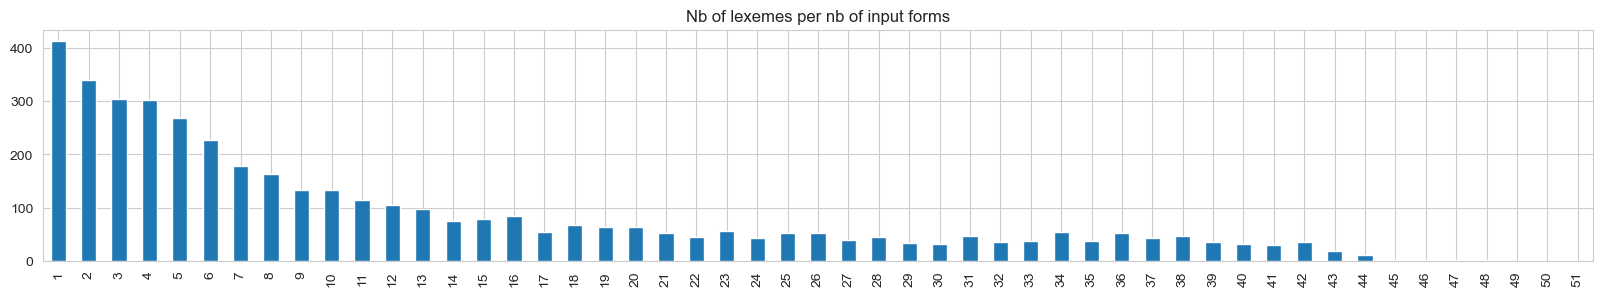

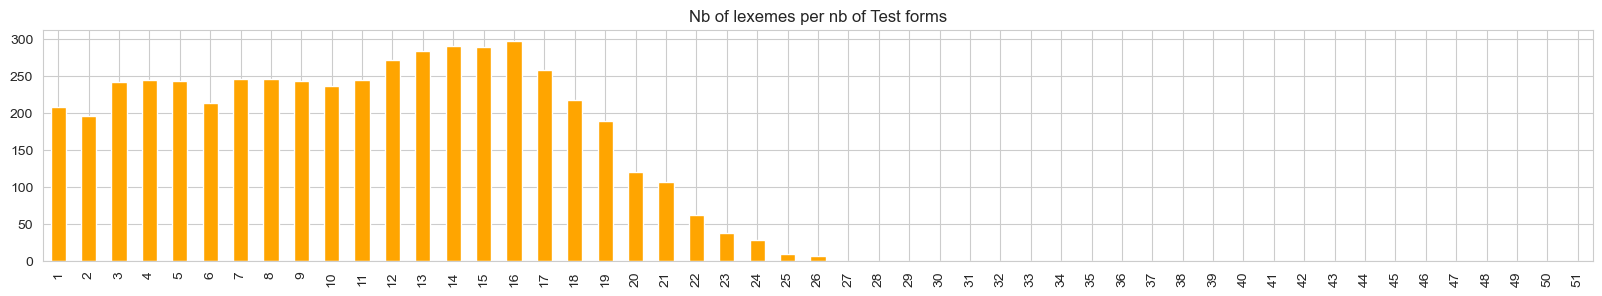

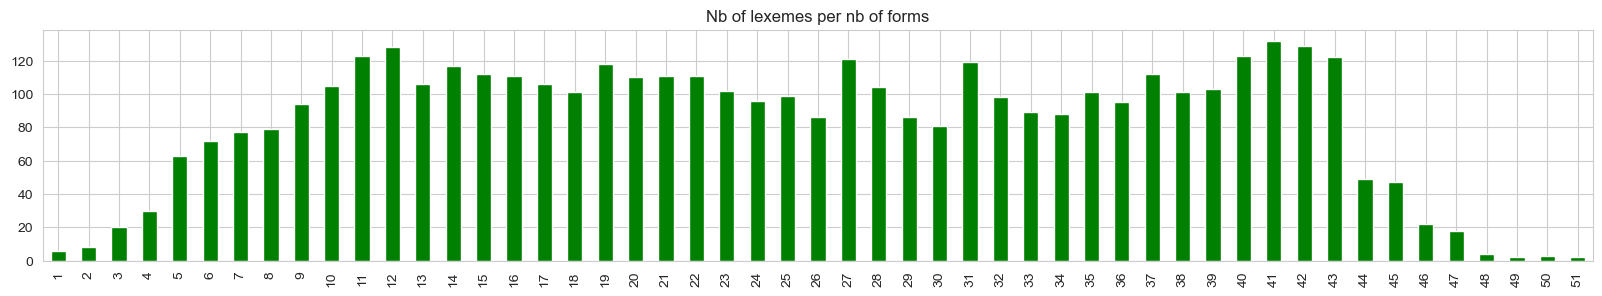

In [6]:
fInput4=repFiles+"vlexique2-S4.csv"
dfInput4=pd.read_csv(fInput4,sep=";")
dfInput4.set_index("lexeme",inplace=True)
# print("input",dfInput4.count().sort_index().sum())
sInput4=dfInput4.T.count().value_counts()
for n in range(1,52):
    if n not in sInput4.index:
        sInput4[n]=0
sInput4.sort_index(inplace=True)
sInput4.plot(kind="bar",figsize=(20,3),title="Nb of lexemes per nb of input forms")
plt.show()
# sInput4

fTest4=repFiles+"vlexique2-R4.csv"
dfTest4=pd.read_csv(fTest4,sep=";")
dfTest4.set_index("lexeme",inplace=True)
# print("Test",dfTest4.count().sort_index().sum())
sTest4=dfTest4.T.count().value_counts()
for n in range(1,52):
    if n not in sTest4.index:
        sTest4[n]=0
sTest4.sort_index(inplace=True)
sTest4.plot(kind="bar",figsize=(20,3),color="orange",title="Nb of lexemes per nb of Test forms")
plt.show()

dfComplete4=dfInput4.copy()
dfComplete4[dfComplete4.isnull()]=dfTest4
sComplete4=dfComplete4.T.count().value_counts()
sComplete4.sort_index(inplace=True)
sComplete4.plot(kind="bar",figsize=(20,3),color="green",title="Nb of lexemes per nb of forms")
plt.show()

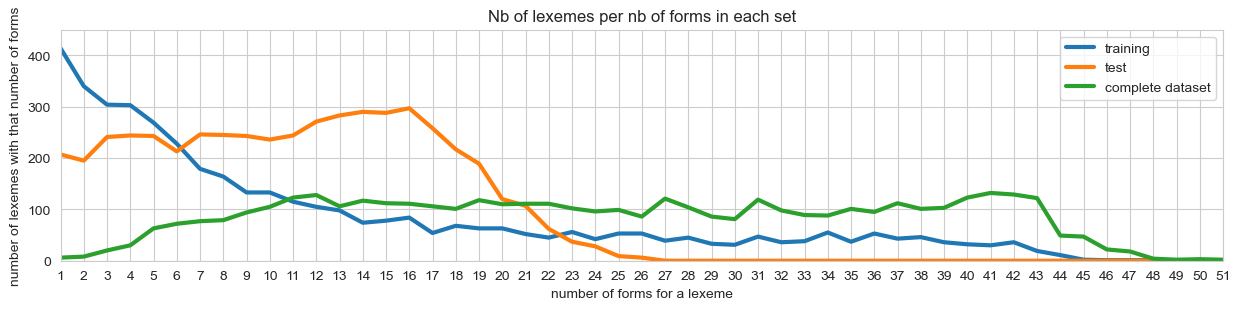

In [7]:
ax=pd.DataFrame({"training":sInput4,"test":sTest4,"complete dataset":sComplete4}).plot(kind="line",linewidth=3,figsize=(15,3),title="Nb of lexemes per nb of forms in each set")
ax.set_xlim(1,51)
ax.set_xlabel("number of forms for a lexeme")
ax.set_ylim(0,450)
ax.set_ylabel("number of lexemes with that number of forms")
ax.set_xticks(range(1,52))
plt.savefig("temp.png",dpi=300,bbox_inches="tight")

In [8]:
cComplete4=dfComplete4[cellOrd].count()
cInput4=dfInput4[cellOrd].count()
dfRemplissage4=pd.DataFrame({"input":cInput4,"complete":cComplete4})
dfRemplissage4["proportion"]=dfRemplissage4.input.astype(str)+"/"+dfRemplissage4.complete.astype(str)
dfRemplissage4["pourcentage"]=dfRemplissage4.input/dfRemplissage4.complete*100
dRemplissage4Prop=dfRemplissage4["proportion"].to_dict()
dRemplissage4Perc=dfRemplissage4["pourcentage"].to_dict()

In [9]:
def getTable(fName):
    df=pd.read_csv(fName,sep=";")
    if "Unnamed: 0" in df.columns:
        df.set_index("Unnamed: 0",inplace=True)
        df.index.rename("lexeme",inplace=True)
    elif "lexeme" in df.columns:
        df.set_index("lexeme",inplace=True)
    for c in cellOrd:
        if c not in df.columns:
            df[c]=np.NaN
    return df[cellOrd]

<Axes: title={'center': 'Direct correct/different'}>

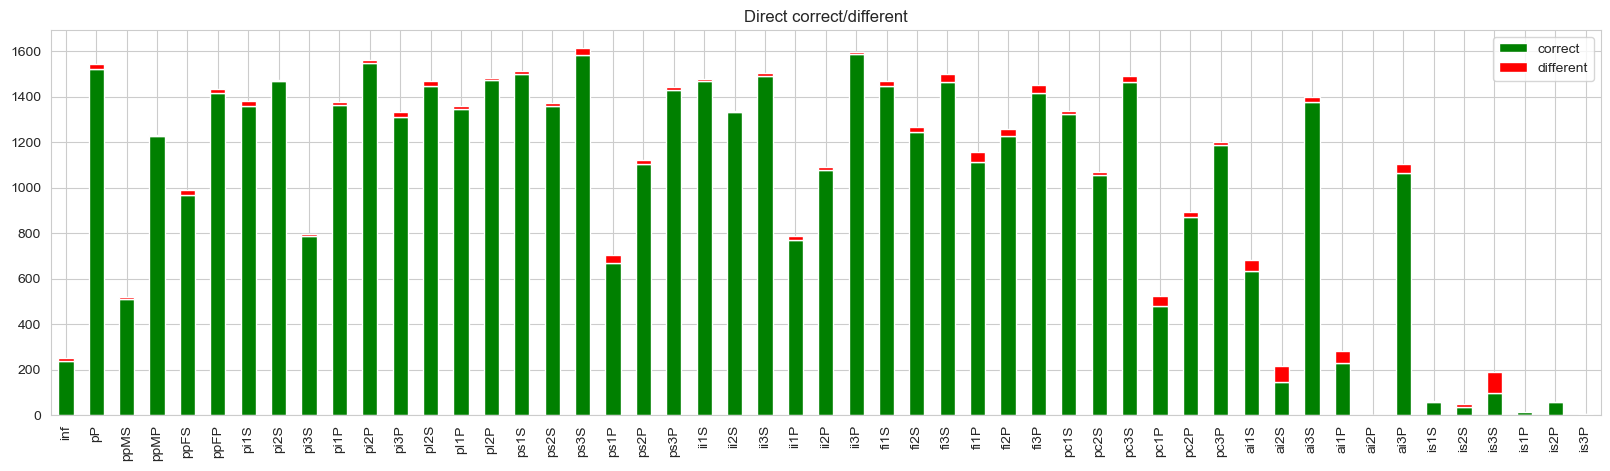

In [10]:
fDirect4Diff=repFiles+"vlexique2-Direct-S4-omp-gold-different.csv"
fDirect4Corr=repFiles+"vlexique2-Direct-S4-omp-gold-correct.csv"

dfDirect4Diff=getTable(fDirect4Diff)
dfDirect4Corr=getTable(fDirect4Corr)
dfDirect4CorrDiff=pd.DataFrame({"correct":dfDirect4Corr.count(),"different":dfDirect4Diff.count()})
dfDirect4CorrDiff.reindex(cellOrd).plot.bar(stacked=True,figsize=(20,5),color=["green","red"],title="Direct correct/different")
    # 

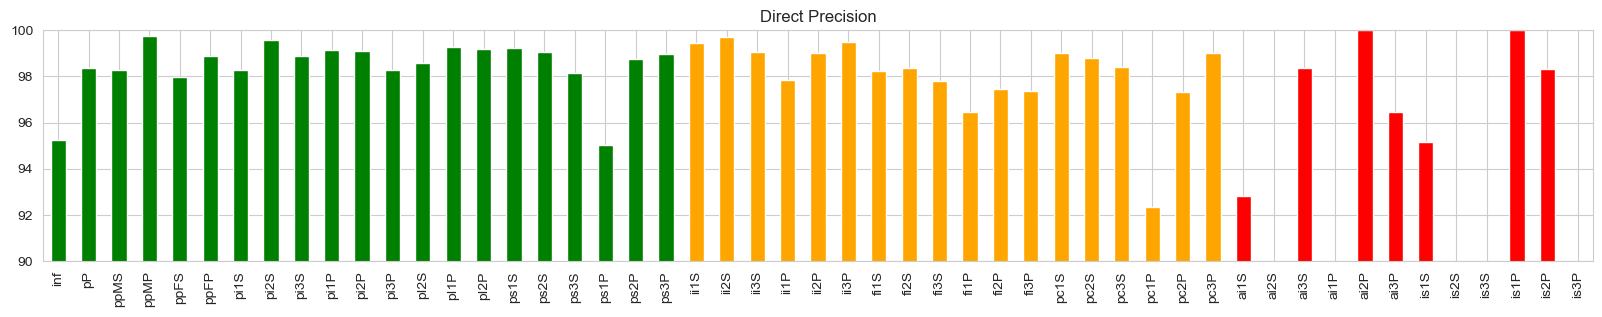

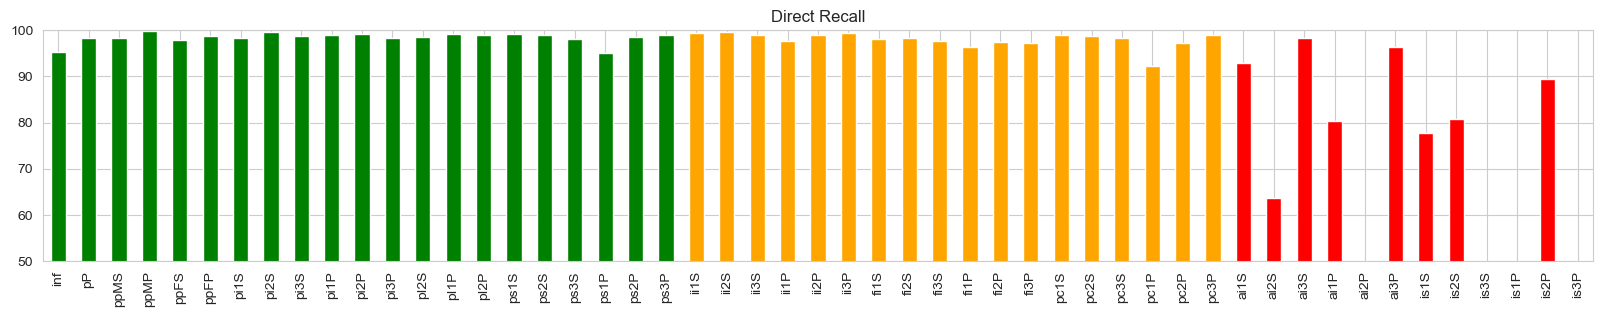

(50.0, 100.0)

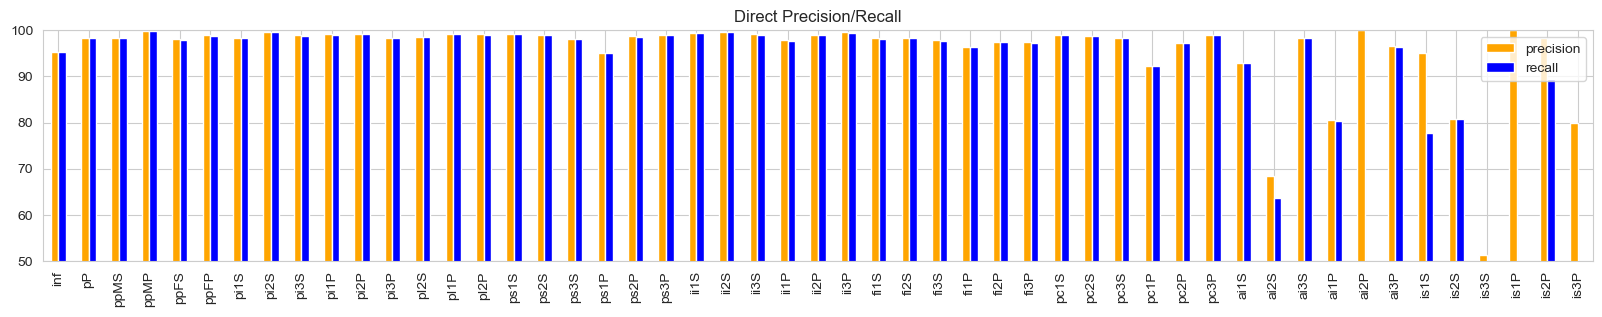

In [11]:
fDirect4Diff=repFiles+"vlexique2-Direct-S4-omp-gold-different.csv"
fDirect4Corr=repFiles+"vlexique2-Direct-S4-omp-gold-correct.csv"
fDirect4Miss=repFiles+"vlexique2-Direct-S4-omp-gold-missing.csv"

dfDirect4Diff=getTable(fDirect4Diff)
sDirect4Diff=dfDirect4Diff.count()
dfDirect4Corr=getTable(fDirect4Corr)
sDirect4Corr=dfDirect4Corr.count()
dfDirect4Miss=getTable(fDirect4Miss)
sDirect4Miss=dfDirect4Miss.count()

dfDirect4Precision=sDirect4Corr/(sDirect4Corr+sDirect4Diff)*100
ax=dfDirect4Precision.plot(kind="bar",color=cellColor,figsize=(20,3),title="Direct Precision") 
ax.set_ylim(90,100)
plt.show()

dfDirect4Recall=sDirect4Corr/(sDirect4Corr+sDirect4Diff+sDirect4Miss)*100
ax=dfDirect4Recall.plot(kind="bar",color=cellColor,figsize=(20,3),title="Direct Recall") 
ax.set_ylim(50,100)
plt.show()

ax=pd.DataFrame({"precision":dfDirect4Precision,"recall":dfDirect4Recall}).plot(kind="bar",
                                                                             color=["orange","blue"],
                                                                             figsize=(20,3),title="Direct Precision/Recall") 
ax.set_ylim(50,100)


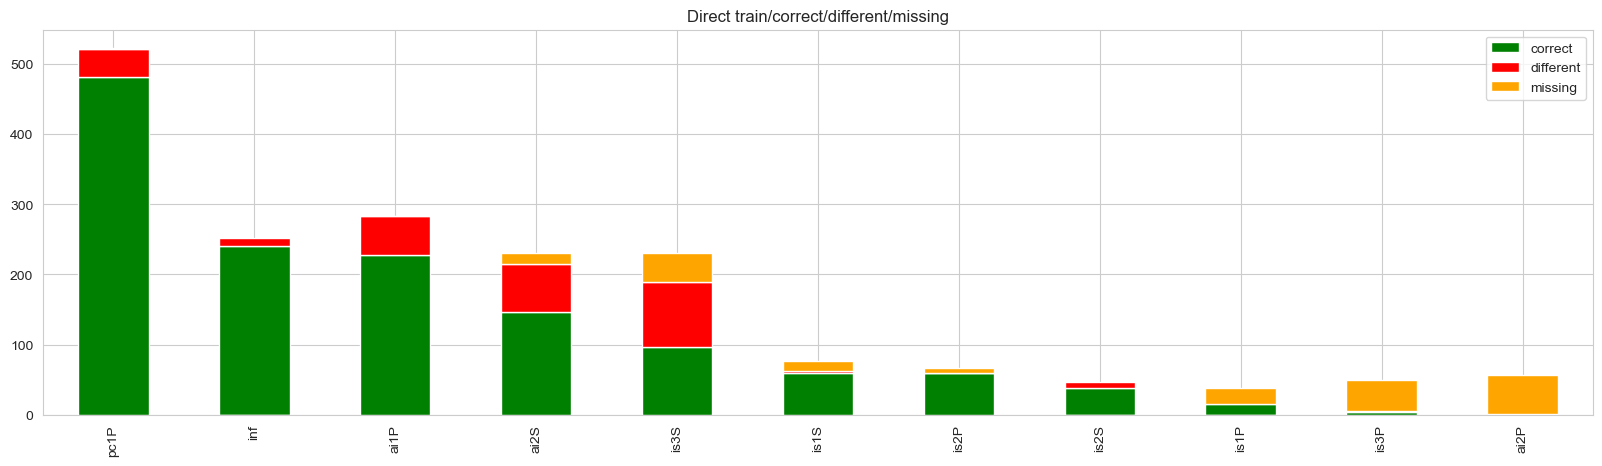

In [76]:
dfDirect4Dist=pd.DataFrame({"correct":dfDirect4Corr.count(),"different":dfDirect4Diff.count(),"missing":dfDirect4Miss.count()})
dfDirect4Dist.sort_values("correct",inplace=True,ascending=False)
dfDirect4Dist.iloc[40:].plot.bar(stacked=True,figsize=(20,5),color=["green","red","orange"],title="Direct train/correct/different/missing")
plt.savefig(repFiles+"Distribution-Direct-cordifmis.png",dpi=300)

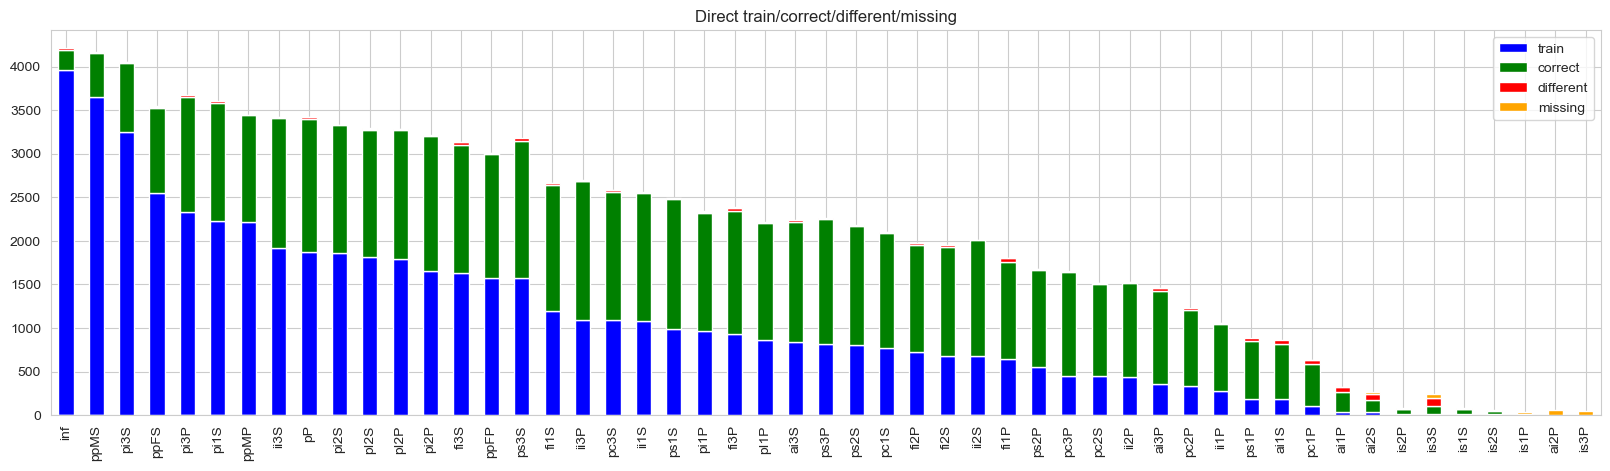

In [74]:
dfDirect4Dist=pd.DataFrame({"train":dfInput4.count(),"correct":dfDirect4Corr.count(),"different":dfDirect4Diff.count(),"missing":dfDirect4Miss.count()})
dfDirect4Dist.sort_values("train",inplace=True,ascending=False)
dfDirect4Dist.plot.bar(stacked=True,figsize=(20,5),color=["blue","green","red","orange"],title="Direct train/correct/different/missing")
plt.savefig(repFiles+"Distribution-Direct.png",dpi=300)

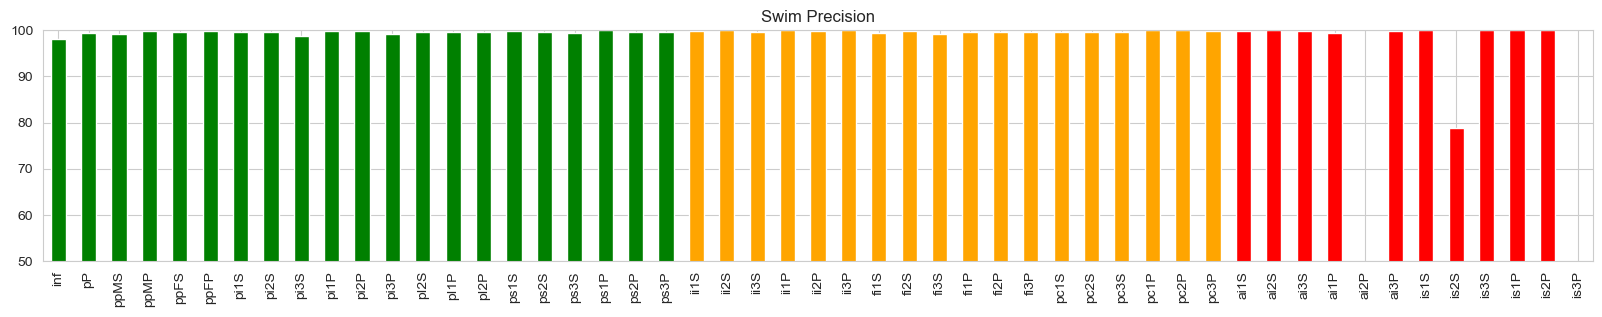

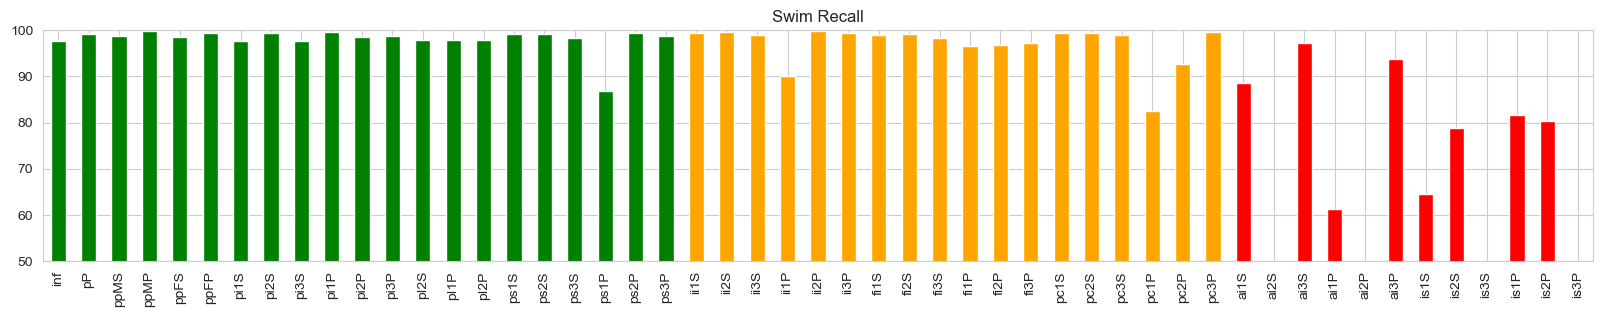

(50.0, 100.0)

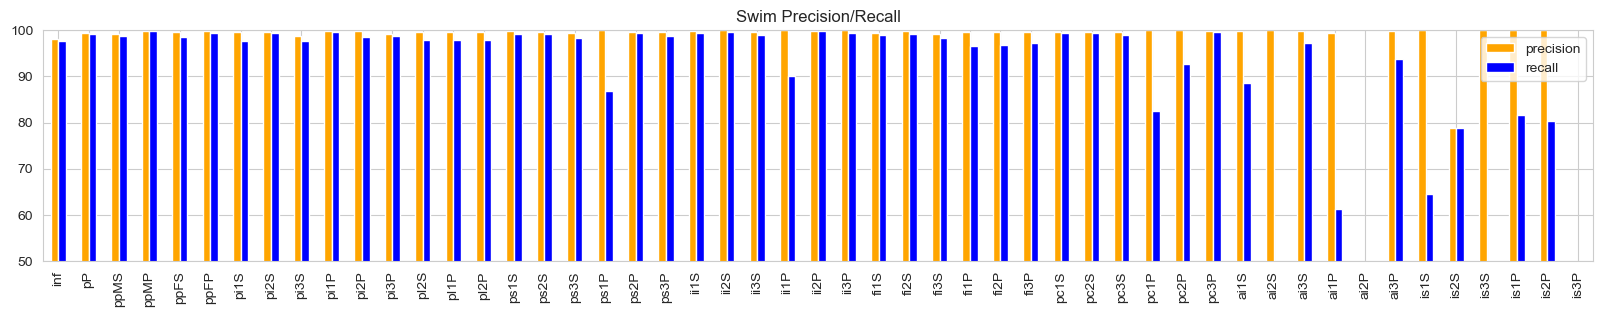

In [13]:
fSwim4Diff=repFiles+"vlexique2-S4-StemSpace-gold-different.csv"
fSwim4Corr=repFiles+"vlexique2-S4-StemSpace-gold-correct.csv"
fSwim4Miss=repFiles+"vlexique2-S4-StemSpace-gold-missing.csv"

dfSwim4Diff=getTable(fSwim4Diff)
sSwim4Diff=dfSwim4Diff.count()
dfSwim4Corr=getTable(fSwim4Corr)
sSwim4Corr=dfSwim4Corr.count()
dfSwim4Miss=getTable(fSwim4Miss)
sSwim4Miss=dfSwim4Miss.count()

dfSwim4Precision=sSwim4Corr/(sSwim4Corr+sSwim4Diff)*100
ax=dfSwim4Precision.plot(kind="bar",color=cellColor,figsize=(20,3),title="Swim Precision") 
ax.set_ylim(50,100)
plt.show()

dfSwim4Recall=sSwim4Corr/(sSwim4Corr+sSwim4Diff+sSwim4Miss)*100
ax=dfSwim4Recall.plot(kind="bar",color=cellColor,figsize=(20,3),title="Swim Recall") 
ax.set_ylim(50,100)
plt.show()

ax=pd.DataFrame({"precision":dfSwim4Precision,"recall":dfSwim4Recall}).plot(kind="bar",
                                                                             color=["orange","blue"],
                                                                             figsize=(20,3),title="Swim Precision/Recall") 
ax.set_ylim(50,100)


<Axes: title={'center': 'Swim correct/different'}>

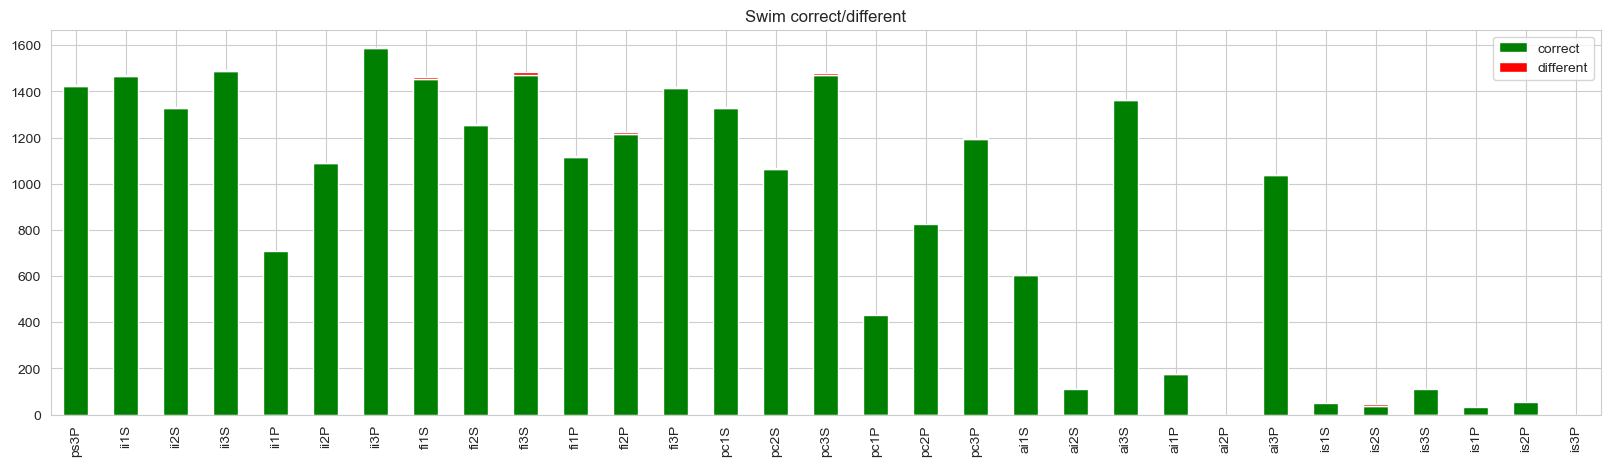

In [60]:

dfSwim4CorrDiff=pd.DataFrame({"correct":dfSwim4Corr.count(),"different":dfSwim4Diff.count()})
dfSwim4CorrDiff.reindex(cellOrd).plot.bar(stacked=True,figsize=(20,5),color=["green","red"],title="Swim correct/different")
    # 

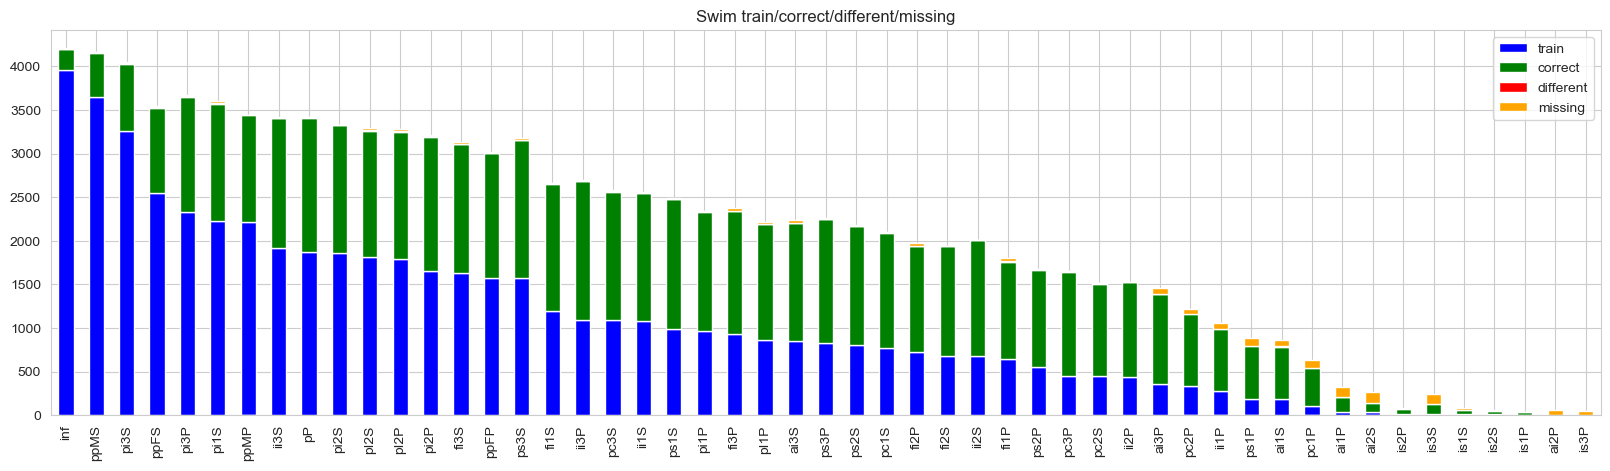

In [63]:
dfSwim4Dist=pd.DataFrame({"train":dfInput4.count(),"correct":dfSwim4Corr.count(),"different":dfSwim4Diff.count(),"missing":dfSwim4Miss.count()})
dfSwim4Dist.sort_values("train",inplace=True,ascending=False)
dfSwim4Dist.plot.bar(stacked=True,figsize=(20,5),color=["blue","green","red","orange"],title="Swim train/correct/different/missing")
plt.savefig(repFiles+"Distribution-Swim.png",dpi=300)

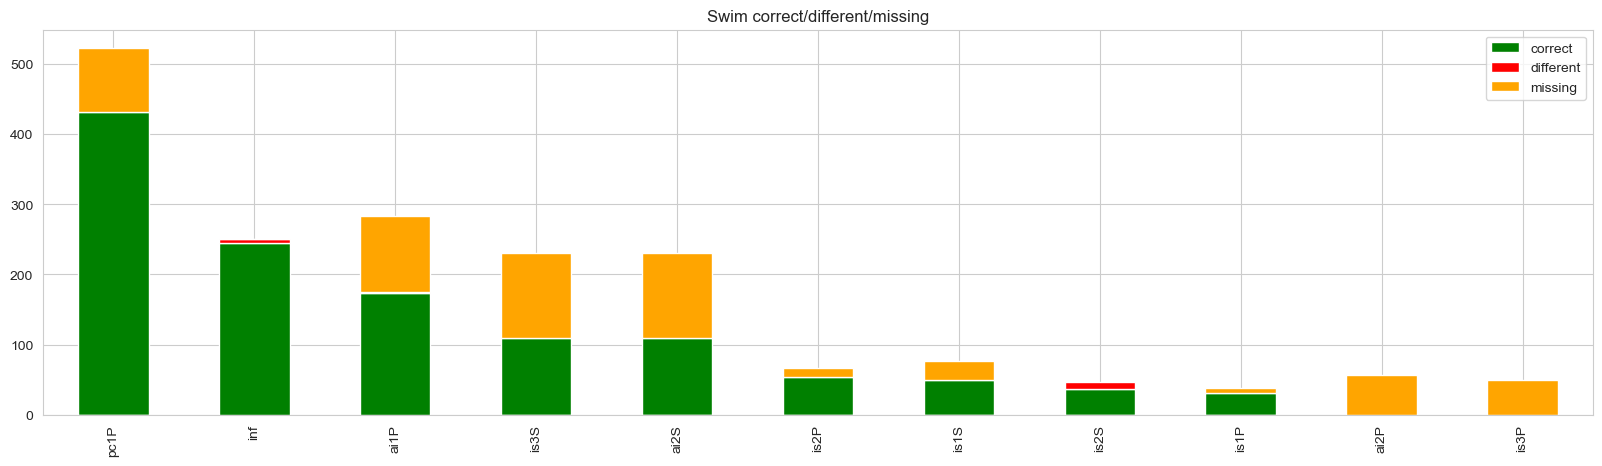

In [75]:
dfSwim4Dist=pd.DataFrame({"correct":dfSwim4Corr.count(),"different":dfSwim4Diff.count(),"missing":dfSwim4Miss.count()})
dfSwim4Dist.sort_values("correct",inplace=True,ascending=False)
dfSwim4Dist.iloc[40:].plot.bar(stacked=True,figsize=(20,5),color=["green","red","orange"],title="Swim correct/different/missing")
plt.savefig(repFiles+"Distribution-Swim-cordifmis.png",dpi=300)

## Tables Précision/Rappel

In [16]:
def makeTabular(dictColours,title="",coulLim=False, cat="V", typeNum="float"):
    tabular=[]
    def makeLine6(tenseCode):
        line=[tenseCode]
        for person in [per+nb for nb in ["S","P"] for per in ["1","2","3"]]:
            case=tenseCode+person
            if case in dictColours:
                if typeNum=="float":
                    line.append("%.1f"%dictColours[case])
                elif typeNum=="string":
                    line.append(dictColours[case])
                else:
                    line.append("%d"%dictColours[case])
            else:
                line.append(" ")
        return r" & ".join(line)+r"\\"

    def makeLine3(tenseCode):
        line=[tenseCode]
        for person in [per+nb for nb in ["S","P"] for per in ["1","2","3"]]:
            if person in ["2S","1P","2P"]:
                case=tenseCode+person
                if case in dictColours:
                    if typeNum=="float":
                        line.append("%.1f"%dictColours[case])
                    elif typeNum=="string":
                        line.append(dictColours[case])
                    else:
                        line.append("%d"%dictColours[case])                    
                else:
                    line.append(" ")
#                line.append(r"\cellcolor{%s}%s"%(dictColours[case],case))
            else:
                line.append(r"---")
        return r" & ".join(line)+r"\\"
    
    def makeLineNF():
        line=[" "]
        for case in ["inf","pP","ppMS","ppMP","ppFS","ppFP"]:
            if case in dictColours:
                if typeNum=="float":
                    line.append("%.1f"%dictColours[case])
                elif typeNum=="string":
                    line.append(dictColours[case])
                else:
                    line.append("%d"%dictColours[case])
            else:
                line.append(" ")
#            line.append(r"\cellcolor{%s}%s"%(dictColours[case],case))
        return r" & ".join(line)+r"\\"

    def makeLineMF(nombre):
        line=[]
        for genre in "mf":
            case=genre+nombre
            if case in dictColours:
                if typeNum=="float":
                    line.append("%.1f"%dictColours[case])
                elif typeNum=="string":
                    line.append(dictColours[case])
                else:
                    line.append("%d"%dictColours[case])                
            # else:
            #     line.append(r"\cellcolor{%s}%s"%("black",case))
        return r" & ".join(line)+r"\\"
    
    def makeLineCoulLim():
        line=[]
        for numLimite,limite in enumerate(listLimites):
            line.append(r"\cellcolor{%s}%s"%(listLimCoul[numLimite],"$<$"+str(limite)))
        return r"\hline\hline "+r" & ".join(line)+r"\\"
        
    if cat=="V":
        top=[
            r"\begin{center}",
            r"\begin{tabular}{rcccccc}",
            r"&1S&2S&3S&1P&2P&3P\\",
            r"\hline"
            ]
        bottom=[
            r"\hline",
            r"\end{tabular}\\",
            title,
            r"\end{center}",
            r"\bigskip",
            r""
            ]
        tabular.append("\n".join(top))
        for tenseCode in ["pi","ii","fi","pc", "ps","ai", "is"]:
            tabular.append(makeLine6(tenseCode))
        tabular.append(makeLine3("pI"))
        tabular.append(r"\hline")
        tabular.append(r"&inf & pP & ppMS &ppMP&ppFS&ppFP\\")
        tabular.append(makeLineNF())
    elif cat=="A":
        top=[
            r"\begin{center}",
            r"\begin{tabular}{cc}",
            r"\hline"
            ]
        bottom=[
            r"\hline",
            r"\end{tabular}\\",
            title,
            r"\end{center}",
            r"\bigskip",
            r""
            ]
        tabular.append("\n".join(top))
        for number in "sp":
            tabular.append(makeLineMF(number))
    if coulLim:
        tabular.append(makeLineCoulLim())
    tabular.append("\n".join(bottom))
    return "\n".join(tabular)

In [17]:
print(makeTabular(dRemplissage4Prop,title="Train/Total",typeNum="string"))
print()
print(makeTabular(dRemplissage4Perc,title="Train/Total"))
print()

\begin{center}
\begin{tabular}{rcccccc}
&1S&2S&3S&1P&2P&3P\\
\hline
pi & 2223/3602 & 1859/3332 & 3254/4050 & 960/2335 & 1657/3215 & 2336/3669\\
ii & 1083/2560 & 674/2010 & 1915/3420 & 274/1062 & 443/1532 & 1097/2689\\
fi & 1197/2662 & 681/1941 & 1634/3130 & 643/1794 & 720/1972 & 926/2375\\
pc & 765/2099 & 447/1513 & 1090/2575 & 110/632 & 332/1223 & 454/1652\\
ps & 983/2494 & 804/2177 & 1569/3179 & 181/882 & 554/1673 & 822/2262\\
ai & 181/865 & 31/262 & 845/2243 & 35/318 & 3/59 & 354/1460\\
is & 10/86 & 10/57 & 13/243 & 3/41 & 15/81 & 2/52\\
pI & --- & 1818/3287 & --- & 862/2219 & 1796/3279 & ---\\
\hline
&inf & pP & ppMS &ppMP&ppFS&ppFP\\
  & 3955/4208 & 1875/3418 & 3648/4167 & 2212/3443 & 2551/3541 & 1579/3011\\
\hline
\end{tabular}\\
Train/Total
\end{center}
\bigskip


\begin{center}
\begin{tabular}{rcccccc}
&1S&2S&3S&1P&2P&3P\\
\hline
pi & 61.7 & 55.8 & 80.3 & 41.1 & 51.5 & 63.7\\
ii & 42.3 & 33.5 & 56.0 & 25.8 & 28.9 & 40.8\\
fi & 45.0 & 35.1 & 52.2 & 35.8 & 36.5 & 39.0\\
pc & 36.4

In [18]:
dictPrecisionCellsDirect=dfDirect4Precision.to_dict()
print(makeTabular(dictPrecisionCellsDirect,title="Direct Precision",coulLim=False, cat="V"))
print()

dictRecallCellsDirect=dfDirect4Recall.to_dict()
print(makeTabular(dictRecallCellsDirect,title="Direct Recall",coulLim=False, cat="V"))
print()


\begin{center}
\begin{tabular}{rcccccc}
&1S&2S&3S&1P&2P&3P\\
\hline
pi & 98.3 & 99.6 & 98.9 & 99.1 & 99.1 & 98.3\\
ii & 99.5 & 99.7 & 99.1 & 97.8 & 99.0 & 99.5\\
fi & 98.2 & 98.3 & 97.8 & 96.5 & 97.5 & 97.4\\
pc & 99.0 & 98.8 & 98.4 & 92.3 & 97.3 & 99.0\\
ps & 99.2 & 99.1 & 98.1 & 95.0 & 98.8 & 99.0\\
ai & 92.8 & 68.4 & 98.4 & 80.6 & 100.0 & 96.5\\
is & 95.2 & 80.9 & 51.3 & 100.0 & 98.3 & 80.0\\
pI & --- & 98.6 & --- & 99.3 & 99.2 & ---\\
\hline
&inf & pP & ppMS &ppMP&ppFS&ppFP\\
  & 95.2 & 98.4 & 98.3 & 99.8 & 98.0 & 98.9\\
\hline
\end{tabular}\\
Direct Precision
\end{center}
\bigskip


\begin{center}
\begin{tabular}{rcccccc}
&1S&2S&3S&1P&2P&3P\\
\hline
pi & 98.3 & 99.6 & 98.7 & 99.1 & 99.1 & 98.3\\
ii & 99.5 & 99.7 & 99.0 & 97.7 & 98.9 & 99.4\\
fi & 98.2 & 98.3 & 97.7 & 96.3 & 97.4 & 97.1\\
pc & 99.0 & 98.7 & 98.3 & 92.2 & 97.3 & 99.0\\
ps & 99.2 & 99.1 & 98.1 & 95.0 & 98.6 & 99.0\\
ai & 92.8 & 63.6 & 98.4 & 80.3 & 1.8 & 96.4\\
is & 77.6 & 80.9 & 42.2 & 39.5 & 89.4 & 8.0\\
pI & --- &

In [19]:
dictPrecisionCellsSwim=dfSwim4Precision.to_dict()
print(makeTabular(dictPrecisionCellsSwim,title="Swim Precision",coulLim=False, cat="V"))
print()

dictRecallCellsSwim=dfSwim4Recall.to_dict()
print(makeTabular(dictRecallCellsSwim,title="Swim Recall",coulLim=False, cat="V"))
print()


\begin{center}
\begin{tabular}{rcccccc}
&1S&2S&3S&1P&2P&3P\\
\hline
pi & 99.6 & 99.7 & 98.7 & 99.7 & 99.8 & 99.1\\
ii & 99.9 & 99.9 & 99.6 & 100.0 & 99.9 & 99.9\\
fi & 99.5 & 99.8 & 99.3 & 99.6 & 99.5 & 99.5\\
pc & 99.7 & 99.5 & 99.7 & 100.0 & 100.0 & 99.7\\
ps & 99.8 & 99.6 & 99.4 & 100.0 & 99.6 & 99.6\\
ai & 99.8 & 100.0 & 99.8 & 99.4 & nan & 99.9\\
is & 100.0 & 78.7 & 100.0 & 100.0 & 100.0 & nan\\
pI & --- & 99.5 & --- & 99.7 & 99.7 & ---\\
\hline
&inf & pP & ppMS &ppMP&ppFS&ppFP\\
  & 98.0 & 99.3 & 99.2 & 99.8 & 99.6 & 99.8\\
\hline
\end{tabular}\\
Swim Precision
\end{center}
\bigskip


\begin{center}
\begin{tabular}{rcccccc}
&1S&2S&3S&1P&2P&3P\\
\hline
pi & 97.8 & 99.4 & 97.7 & 99.6 & 98.6 & 98.7\\
ii & 99.3 & 99.6 & 98.9 & 90.0 & 99.8 & 99.4\\
fi & 99.0 & 99.2 & 98.2 & 96.5 & 96.7 & 97.2\\
pc & 99.3 & 99.4 & 98.9 & 82.4 & 92.7 & 99.5\\
ps & 99.1 & 99.2 & 98.3 & 86.7 & 99.4 & 98.8\\
ai & 88.6 & 47.2 & 97.3 & 61.3 & 0.0 & 93.8\\
is & 64.5 & 78.7 & 47.8 & 81.6 & 80.3 & 0.0\\
pI & --

In [20]:
dfCompPrecision=pd.DataFrame({"direct":dictPrecisionCellsDirect,"swim":dictPrecisionCellsSwim})
dfCompPrecision["percentage"]=dfCompPrecision.direct.round(1).astype(str)+" | "+dfCompPrecision.swim.round(1).astype(str)
dictCompPrecision=dfCompPrecision.percentage.to_dict()

print(makeTabular(dictCompPrecision,title="Precision Direct | Swim",coulLim=False, cat="V", typeNum="string"))
print()

dfCompRecall=pd.DataFrame({"direct":dictRecallCellsDirect,"swim":dictRecallCellsSwim})
dfCompRecall["percentage"]=dfCompRecall.direct.round(1).astype(str)+" | "+dfCompRecall.swim.round(1).astype(str)
dictCompRecall=dfCompRecall.percentage.to_dict()

print(makeTabular(dictCompRecall,title="Recall Direct | Swim",coulLim=False, cat="V", typeNum="string"))
print()


\begin{center}
\begin{tabular}{rcccccc}
&1S&2S&3S&1P&2P&3P\\
\hline
pi & 98.3 | 99.6 & 99.6 | 99.7 & 98.9 | 98.7 & 99.1 | 99.7 & 99.1 | 99.8 & 98.3 | 99.1\\
ii & 99.5 | 99.9 & 99.7 | 99.9 & 99.1 | 99.6 & 97.8 | 100.0 & 99.0 | 99.9 & 99.5 | 99.9\\
fi & 98.2 | 99.5 & 98.3 | 99.8 & 97.8 | 99.3 & 96.5 | 99.6 & 97.5 | 99.5 & 97.4 | 99.5\\
pc & 99.0 | 99.7 & 98.8 | 99.5 & 98.4 | 99.7 & 92.3 | 100.0 & 97.3 | 100.0 & 99.0 | 99.7\\
ps & 99.2 | 99.8 & 99.1 | 99.6 & 98.1 | 99.4 & 95.0 | 100.0 & 98.8 | 99.6 & 99.0 | 99.6\\
ai & 92.8 | 99.8 & 68.4 | 100.0 & 98.4 | 99.8 & 80.6 | 99.4 & 100.0 | nan & 96.5 | 99.9\\
is & 95.2 | 100.0 & 80.9 | 78.7 & 51.3 | 100.0 & 100.0 | 100.0 & 98.3 | 100.0 & 80.0 | nan\\
pI & --- & 98.6 | 99.5 & --- & 99.3 | 99.7 & 99.2 | 99.7 & ---\\
\hline
&inf & pP & ppMS &ppMP&ppFS&ppFP\\
  & 95.2 | 98.0 & 98.4 | 99.3 & 98.3 | 99.2 & 99.8 | 99.8 & 98.0 | 99.6 & 98.9 | 99.8\\
\hline
\end{tabular}\\
Precision Direct | Swim
\end{center}
\bigskip


\begin{center}
\begin{tabular}{rcc

# Corrélations

In [21]:
print("dataset",dfComplete4.count().corr(dfSwim4Precision))
print("train",dfInput4.count().corr(dfSwim4Precision))
print("test",(dfComplete4.count()-dfInput4.count()).corr(dfSwim4Precision))
print("test/train",((dfComplete4.count()-dfInput4.count())/dfInput4.count()).corr(dfSwim4Precision))

dataset 0.17839285850486417
train 0.07203141042204453
test 0.29461080585568417
test/train -0.04338254986019139


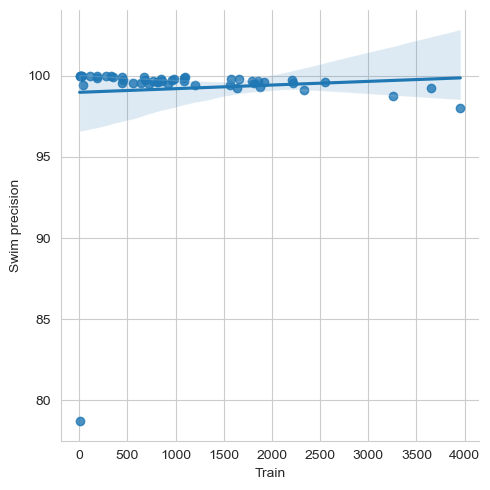

In [22]:
dfLocal=dfComplete4.count()-dfInput4.count()
dfLocal=dfComplete4.count()
dfLocal=dfInput4.count()
dfCorrelation=pd.DataFrame({"Train":dfLocal,"Swim precision":dfSwim4Precision})

# ax=dfCorrelation.plot.scatter(x="Test",y="Swim precision")
# ax.set_ylim(97.5,100.1)
ax=sns.lmplot(x='Train',y='Swim precision',data=dfCorrelation,fit_reg=True) 
plt.savefig(repFiles+"CorrelationRL-SwimPrecision-Train.png",dpi=300)

In [23]:
condClore=(dfInput4["inf"].notnull())&(dfInput4["pi1S"].notnull())&(dfInput4["pi3S"].notnull())&\
          (dfInput4["ppMS"].notnull())&(dfInput4["ppMP"].notnull())&(dfInput4["ppFS"].notnull())&(dfInput4["ppFP"].notnull())
lClore=dfInput4.loc[condClore].T.count().loc[lambda x: x==7].index.tolist()
dfInput4[dfInput4.index.isin(lClore)]

,ai1P,ai1S,ai2P,ai2S,ai3P,ai3S,fi1P,fi1S,fi2P,fi2S,...,ppFP,ppFS,ppMP,ppMS,ps1P,ps1S,ps2P,ps2S,ps3P,ps3S
lexeme,,,,,,,,,,,,,,,,,,,,,
clore,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,kloz,kloz,klo,klo,NaN,NaN,NaN,NaN,NaN,NaN
convier,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,kôvje,kôvje,kôvje,kôvje,NaN,NaN,NaN,NaN,NaN,NaN
encastrer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,âkastre,âkastre,âkastre,âkastre,NaN,NaN,NaN,NaN,NaN,NaN
estropier,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,EstrOpje,EstrOpje,EstrOpje,EstrOpje,NaN,NaN,NaN,NaN,NaN,NaN
éditer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Edite,Edite,Edite,Edite,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
dfInput4[dfInput4.index=="clore"].T.dropna()

lexeme,clore
inf,klOr
pi1S,klo
pi3S,klo
ppFP,kloz
ppFS,kloz
ppMP,klo
ppMS,klo


In [25]:
dfInput4[dfInput4.index=="éditer"].T.dropna()

lexeme,éditer
inf,Edite
pi1S,Edit
pi3S,Edit
ppFP,Edite
ppFS,Edite
ppMP,Edite
ppMS,Edite


## Regroupements par temps et par personne

In [37]:
dfRemplissage4["tiroir"]=dfRemplissage4.index.str[:2]
dfRemplissage4["personne"]=dfRemplissage4.index.str[2:]
dfRemplissage4["test"]=dfRemplissage4.complete-dfRemplissage4.input
dfRemplissage4

,input,complete,proportion,pourcentage,tiroir,personne,test
inf,3955,4208,3955/4208,93.987643,in,f,253
pP,1875,3418,1875/3418,54.856641,pP,,1543
ppMS,3648,4167,3648/4167,87.544996,pp,MS,519
ppMP,2212,3443,2212/3443,64.246297,pp,MP,1231
ppFS,2551,3541,2551/3541,72.041796,pp,FS,990
ppFP,1579,3011,1579/3011,52.441049,pp,FP,1432
pi1S,2223,3602,2223/3602,61.715713,pi,1S,1379
pi2S,1859,3332,1859/3332,55.792317,pi,2S,1473
pi3S,3254,4050,3254/4050,80.345679,pi,3S,796
pi1P,960,2335,960/2335,41.113490,pi,1P,1375


['in', 'pP', 'pp', 'pi', 'pI', 'ps', 'ii', 'fi', 'pc', 'ai', 'is']

<Axes: title={'center': 'Gold train/test'}, xlabel='tiroir'>

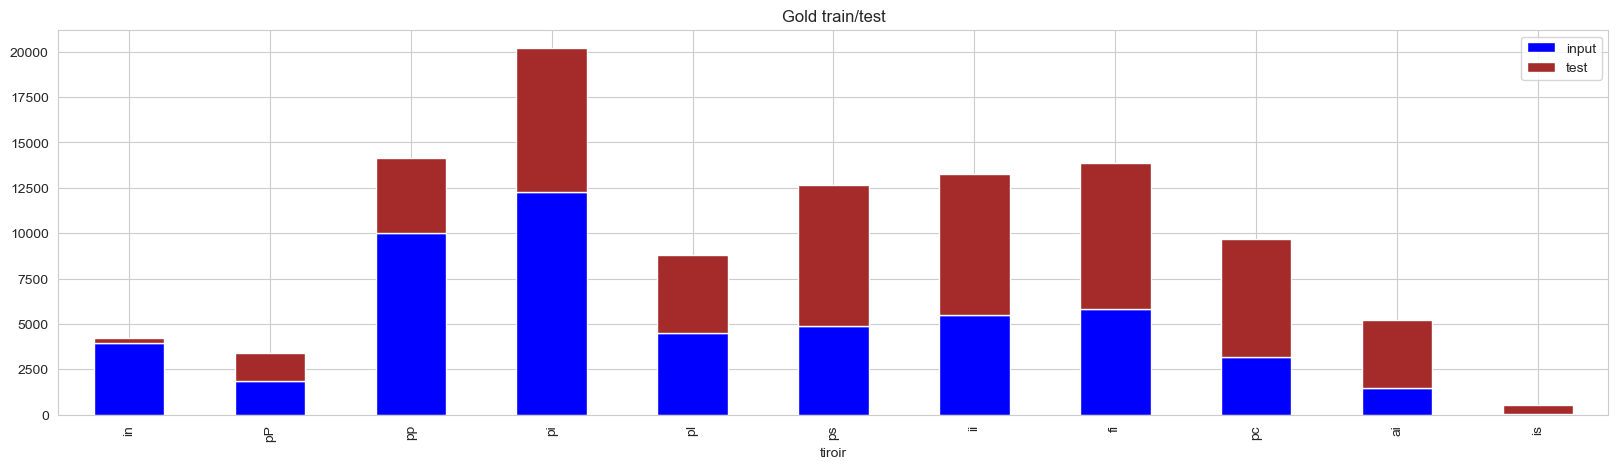

In [45]:
dfInOut4Tiroir=dfRemplissage4[["input","test","tiroir"]].groupby("tiroir").sum()
dfInOut4Tiroir=dfInOut4Tiroir.reindex(['in', 'pP', 'pp', 'pi', 'pI', 'ps', 'ii', 'fi', 'pc', 'ai', 'is'])
dfInOut4Tiroir.plot.bar(stacked=True,figsize=(20,5),color=["blue","brown"],title="Gold train/test")

In [52]:
dfInOutPersonne=dfRemplissage4[["input","test","personne"]].groupby("personne").sum()
dfInOutPersonne.rename(index={"":"pP","f":"inf"},inplace=True)
dfInOutPersonne.reindex("inf pP MS MP FS FP 1S 2S 3S 1P 2P 3P".split())

,input,test
personne,,
inf,3955,253
pP,1875,1543
MS,3648,519
MP,2212,1231
FS,2551,990
FP,1579,1432
1S,6442,7926
2S,6324,8255
3S,10320,8520


<Axes: title={'center': 'Gold train/test'}, xlabel='personne'>

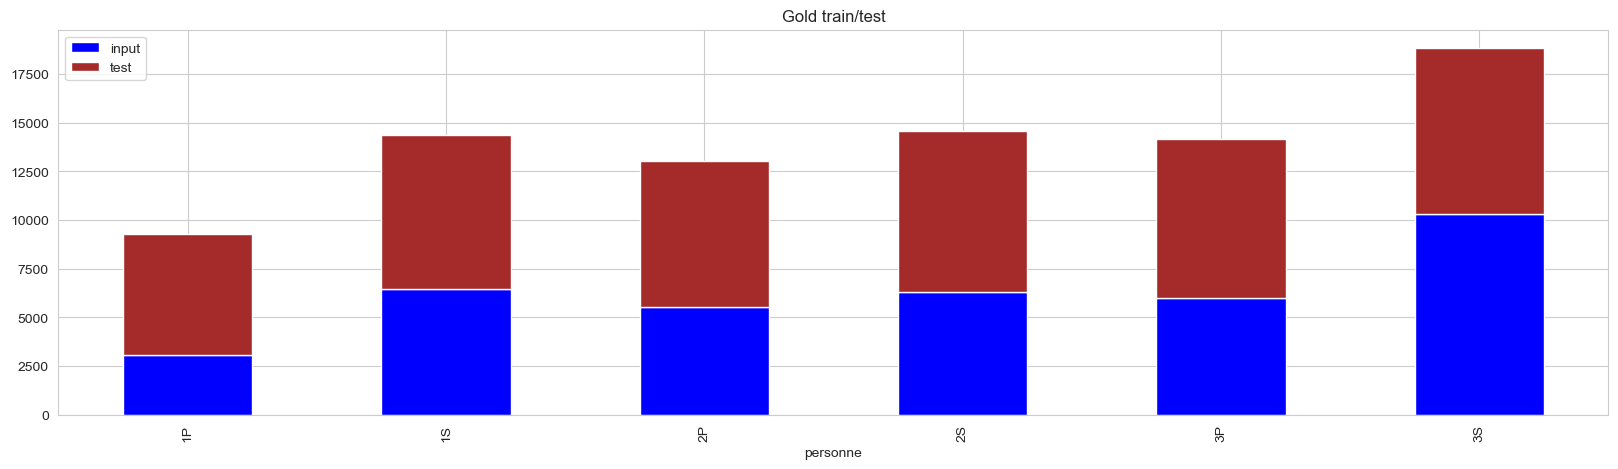

In [56]:
dfInOutPersonne[dfInOutPersonne.index.isin("1S 2S 3S 1P 2P 3P".split())].plot.bar(stacked=True,figsize=(20,5),color=["blue","brown"],title="Gold train/test")